# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  

**Grupo:** 1

Caio Cordeiro Fabri - 2023027939

Carolina Penido Barcellos - 2024024054

Isadora Silva Drumond - 2024074485

Letícia Ribeiro Miranda - 2021095686

**Dataset:** Heart Disease

**Tarefa de mineração:** Classificação

**Data da entrega:** 14/06/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Heart Disease |
| Link público do dataset | https://www.kaggle.com/datasets/oktayrdeki/heart-disease |
| Número de linhas | 10.000 |
| Número de colunas | 21 |
| Tarefa de mineração | Classificação |
| LLM usada na Trilha A | Gemini PRO |
| LLM usada na Trilha B | Gemini PRO |
| Link da conversa — Trilha A | https://gemini.google.com/share/ff697b4549d3  |
| Link da conversa — Trilha B | https://gemini.google.com/share/2911ed7a1007  |

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Monitoramento e Avaliação | Em problemas de classificação médica, avaliar corretamente os modelos é essencial, principalmente para evitar falsos negativos, que podem representar pacientes doentes classificados incorretamente como saudáveis | Será solicitado explicitamente no prompt que a LLM sugira métricas adequadas para o contexto médico, proponha validações robustas e apresente análises críticas, evitando conclusões baseadas apenas em Acurácia |
| Explicabilidade | Modelos aplicados à área da saúde precisam apresentar transparência e interpretabilidade, permitindo compreender os fatores associados ao risco cardiovascular | Será instruído no prompt que a LLM deve escolher modelos mais interpretáveis, fornecer justificativas para os parâmetros utilizados, produzir análises claras das variáveis mais importantes e sugerir visualizações que facilitem a interpretação |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [94]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "dados/heart_disease.csv"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "classificacao"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = "Heart Disease Status"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = "[INSERIR_COLUNA_DE_TRANSACOES]"

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")

Configuração carregada.
Tarefa definida: classificacao


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

Neste projeto, investigamos a previsão do risco de desenvolvimento de doenças cardiovasculares por meio de técnicas de mineração de dados. A tarefa principal é a **classificação supervisionada**.

A escolha do *Heart Disease Dataset* é altamente relevante porque ele concentra indicadores médicos essenciais (como pressão arterial, níveis de colesterol, marcadores inflamatórios como CRP e Homocisteína) e comportamentais (IMC, hábitos de sono e exercício). Esperamos obter modelos capazes de identificar precocemente os fatores que mais influenciam o risco cardiovascular, servindo como base confiável para sistemas de apoio à decisão clínica e triagem médica.

- **Contexto:** As doenças cardiovasculares estão entre as principais causas de morte no mundo. A prevenção e a detecção precoce dos fatores de risco associados a essas doenças são essenciais para melhorar o prognóstico dos pacientes, salvar vidas e otimizar a distribuição de recursos hospitalares e de saúde pública.

- **Problema:** A dificuldade de prever com precisão e rapidez se um indivíduo apresenta alto risco de desenvolver uma doença cardíaca analisando, de forma manual ou isolada, uma grande variedade de características fisiológicas, condições pré-existentes (como diabetes) e hábitos de vida. 

- **Possíveis interessados:** Profissionais da saúde (médicos, enfermeiros, equipes de triagem), pesquisadores clínicos, analistas de dados de saúde e formuladores de políticas públicas focadas em prevenção.

- **Decisões apoiadas pela análise:** A classificação apoiará a criação de sistemas de triagem inteligente em clínicas e hospitais, ajudando a priorizar o atendimento preventivo para grupos de alto risco, personalizar tratamentos e auxiliar os médicos na demonstração clara de como a mudança de certos hábitos (como tabagismo ou dieta) pode alterar a previsão de risco do paciente.

- **Limitações iniciais conhecidas:** Sabe-se que conjuntos de dados de saúde podem conter ruídos, valores ausentes ou inconsistências naturais da coleta médica. Pode existir uma alta correlação entre certas variáveis e um provável desbalanceamento entre pacientes saudáveis e doentes, o que pode enviesar o modelo. Além disso, resultados incorretamente parametrizados podem gerar modelos preditivos com baixo poder de generalização para novos pacientes.


> Este texto deve ser escrito pelo grupo. Não copie a descrição do dataset sem contextualizar o problema de mineração de dados.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O propósito do dataset é reunir diversos indicadores de saúde e fatores de risco associados a doenças cardiovasculares, permitindo analisar tendências, identificar os principais fatores de risco e contribuir com pesquisas focadas na saúde cardíaca.

### Origem dos dados

Os dados foram disponibilizados pelo autor Oktay Ördekçi na plataforma Kaggle. O conjunto é destinado a pesquisas de saúde e cientistas de dados.

Link público: https://www.kaggle.com/datasets/oktayrdeki/heart-disease


### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| **Age** | Numérico | Idade do indivíduo | Fator demográfico na análise de risco à saúde |
| **Gender** | Categórico | Gênero do indivíduo (Masculino/Feminino) | Fator demográfico secundário |
| **Blood Pressure** | Numérico | Pressão arterial sistólica | Fator para caracterizar o estado cardiovascular do paciente  |
| **Cholesterol Level** | Numérico | Nível de colesterol total | Fator crucial para determinar o estado metabólico e cardiovascular |
| **Exercise Habits** | Categórico | Hábitos de exercício físico (Baixo, Médio, Alto) | Auxilia na análise de hábitos de vida associados à saúde cardíaca |
| **Smoking** | Booleano / Categórico | Hábito de fumar (Sim/Não) | Contribui significativamente para uma maior chance de desenvolvimento da doença |
| **Family Heart Disease** | Booleano / Categórico | Histórico familiar de doença cardíaca (Sim/Não) | Fator de risco genético com contribuição significativa ao diagnóstico |
| **Diabetes** | Booleano / Categórico | Presença de diabetes (Sim/Não) | Comorbidade que eleva a probabilidade de desenvolver doenças cardíacas |
| **BMI** | Numérico | Índice de massa corporal (IMC) | Indicador fundamental para análise de obesidade e hábitos de vida |
| **High Blood Pressure** | Booleano / Categórico | Presença de hipertensão (Sim/Não) | Variável associada diretamente a maior probabilidade de risco cardíaco |
| **Low HDL Cholesterol** | Booleano / Categórico | Baixo HDL (Sim/Não) | Fator de risco metabólico |
| **High LDL Cholesterol** | Booleano / Categórico | Alto LDL (Sim/Não) | Fator de risco metabólico |
| **Alcohol Consumption** | Categórico | Nível de consumo de álcool (Nenhum, Baixo, Médio, Alto) | Indicador comportamental e de estilo de vida |
| **Stress Level** | Categórico | Nível de estresse (Baixo, Médio, Alto) | Fator diretamente relacionado ao risco cardiovascular |
| **Sleep Hours** | Numérico | Quantidade de horas de sono | Auxilia na análise de hábitos de vida que podem reduzir ou aumentar o risco |
| **Sugar Consumption** | Categórico | Consumo de açúcar (Baixo, Médio, Alto) | Marcador de risco metabólico ligado aos hábitos alimentares |
| **Triglyceride Level** | Numérico | Nível de triglicerídeos | Ajuda a caracterizar o estado cardiovascular e metabólico |
| **Fasting Blood Sugar** | Numérico | Glicemia em jejum | Marcador metabólico de alto risco, fortemente associado a diabetes |
| **CRP Level** | Numérico | Nível de proteína C reativa | Marcador inflamatório frequentemente associado ao aumento do risco cardíaco |
| **Homocysteine Level** | Numérico | Nível de homocisteína | Marcador vascular importante associado ao aumento do risco cardiovascular |
| **Heart Disease Status** | Booleano / Categórico | Presença ou ausência de doença cardíaca (Sim/Não) | Variável alvo da tarefa de classificação deste problema de negócio |


### Relação com o problema de negócio

Este dataset é adequado para o problema escolhido porque contém a exata sobreposição de atributos clínicos (pressão arterial, diabetes, marcadores inflamatórios) e comportamentais (exercício, sono, tabagismo) necessários para investigar e prever a probabilidade de uma doença cardíaca. Como o conjunto possui uma variedade rica de variáveis numéricas e categóricas muito bem definidas, ele atende plenamente aos requisitos técnicos para a aplicação de algoritmos clássicos de classificação supervisionada. Com isso, os resultados extraídos deste dataset poderão ser aplicados diretamente em sistemas práticos de triagem e apoio à decisão médica na prevenção cardiovascular.


## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| **Monitoramento e Avaliação** | Em problemas de classificação médica, avaliar corretamente os modelos preditivos é essencial, principalmente para evitar falsos negativos (ou seja, classificar incorretamente um paciente doente como saudável), o que representaria um risco gravíssimo | Espera-se que a LLM abandone o uso superficial da "Acurácia" e sugira métricas mais adequadas para o contexto médico. Além disso, espera-se que ela proponha validações mais robustas e análises críticas dos resultados |
| **Explicabilidade** | Modelos aplicados à área da saúde precisam apresentar extrema transparência e interpretabilidade técnica, permitindo que os profissionais compreendam claramente como os fatores clínicos e comportamentais influenciam o risco cardiovascular do paciente | Espera-se que a LLM escolha algoritmos naturalmente mais interpretáveis, forneça justificativas claras para os parâmetros utilizados, produza análises sobre a importância das variáveis e sugira visualizações gráficas que facilitem a interpretação médica |

### Hipótese experimental

Esperamos que, ao explicitar as diretrizes de **Monitoramento e Avaliação** e de **Explicabilidade**, a LLM proponha uma solução com métricas muito mais rigorosas e adequadas ao contexto da saúde e com maior interpretabilidade, em comparação com a solução baseline. Enquanto a baseline deve focar em respostas rápidas e geração de código padrão com análises superficiais, a trilha guiada deverá fornecer justificativas metodológicas transparentes, garantindo modelos mais confiáveis e alinhados à realidade da tomada de decisão médica.

### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini PRO 

**Data de acesso:** 03/06/2026  

**Link da conversa:** https://gemini.google.com/share/ff697b4549d3 

**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o 'Heart Disease Dataset'. 
A tarefa é de classificação supervisionada para prever a presença de doenças cardíacas usando atributos clínicos e comportamentais. 

Ajude-me a formular o Business Understanding, incluindo o objetivo do dataset, a origem dos dados, características gerais e a relação com o problema de negócio (sistemas de apoio à decisão médica).
```

#### Síntese da resposta da LLM

A LLM estruturou a resposta de forma direta, dividindo-a nos tópicos de Objetivo, Origem, Características e Relação com o Negócio (posicionando o modelo como um Sistema de Apoio à Decisão Médica para triagem e segunda opinião). No entanto, por ser uma interação genérica, a LLM cometeu "alucinações" sobre o contexto dos dados: ela presumiu tratar-se da clássica base de dados de Cleveland, citando exames que não existem no dataset escolhido pelo grupo (como resultados de eletrocardiograma, teste ergométrico e variáveis alvo de 0 a 4). Um ponto de destaque para a análise crítica é que, mesmo na trilha baseline e sem o prompt guiado, o modelo demonstrou um conhecimento prévio sobre o domínio da saúde ao alertar sobre o perigo dos "falsos negativos" e sugerir o uso das métricas Recall e F1-Score, ainda que a análise geral dos dados tenha sido superficial e baseada em suposições incorretas.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini PRO 

**Data de acesso:** 03/06/2026  

**Link da conversa:** https://gemini.google.com/share/2911ed7a1007 

**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o 'Heart Disease Dataset'. 
A tarefa é de classificação supervisionada para prever a presença de doenças cardíacas usando atributos clínicos e comportamentais. 
Ajude-me a formular o Business Understanding.

Considere explicitamente as seguintes diretrizes de IA responsável:
1. Monitoramento e Avaliação: Em problemas de classificação médica, avaliar corretamente os modelos é essencial, principalmente para evitar falsos negativos (classificar pacientes doentes como saudáveis).
2. Explicabilidade: Modelos aplicados à área da saúde precisam apresentar transparência, permitindo compreender claramente quais fatores estão associados ao risco cardiovascular.

Além da descrição do problema, indique riscos, limitações e critérios metodológicos rigorosos que deveriam orientar a solução de mineração de dados.

```

#### Síntese da resposta da LLM

A resposta gerada na Trilha B confirmou a hipótese experimental do grupo: a explicitação das diretrizes de IA Responsável elevou significativamente o rigor metodológico e crítico da proposta. A LLM estruturou a resposta focando no impacto clínico, destacando a assimetria dos erros médicos e justificando que Falsos Negativos custam vidas e devem ser evitados.
Para atender à diretriz de Monitoramento e Avaliação, a LLM abandonou a Acurácia e recomendou o uso primário do Recall, introduzindo práticas avançadas não citadas na baseline, como o Ajuste do Limiar de Decisão (Threshold Tuning) para priorizar a sensibilidade e a Validação Cruzada Estratificada para evitar overfitting. Para a diretriz de Explicabilidade, a IA exigiu a priorização de modelos "caixa branca" (como Árvores de Decisão) e sugeriu a aplicação de técnicas post-hoc, como os Valores SHAP, para mapear a contribuição das variáveis caso modelos "caixa preta" (como Random Forest e SVM) sejam adotados.
Ponto de atenção (Alucinação contextual): Apesar da notável superioridade técnica da interação guiada, a LLM apresentou falhas de contexto. Assim como na Trilha A, o modelo assumiu equivocadamente que o dataset utilizado seria a base histórica de Cleveland (UCI), citando atributos e exames que não existem na base escolhida do Kaggle (como "resultados de eletrocardiograma" e "depressão do segmento ST") e apontando vieses de representatividade de gênero baseados nessa suposição incorreta. Isso demonstra para a análise crítica do projeto que as diretrizes éticas melhoram a estruturação metodológica, mas não impedem a LLM de "alucinar" informações se o dicionário de dados (schema) não for fornecido no prompt.

**Em ambas as Trilhas, para evitar conflitos, optamos por especificar o banco que estamos utilizando para as próximas etapas do trabalho prático. Com a mensagem: O dataset que estou utilizando é o Heart Disease Dataset do Kaggle. Ele possui 10.000 linhas e os seguintes 21 atributos: Age, Gender, Blood Pressure, Cholesterol Level, Exercise Habits, Smoking, Family Heart Disease, Diabetes, BMI, High Blood Pressure, Low HDL Cholesterol, High LDL Cholesterol, Alcohol Consumption, Stress Level, Sleep Hours, Sugar Consumption, Triglyceride Level, Fasting Blood Sugar, CRP Level, Homocysteine Level e a variável alvo Heart Disease Status.**

## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| **Clareza do problema** | Definiu o problema de forma correta, voltado para prever doenças coronarianas usando modelos de classificação. | Estruturou o problema de forma mais robusta, conceituando o modelo explicitamente como um Sistema de Apoio à Decisão Clínica (CDSS). | A Trilha B demonstrou maior maturidade ao posicionar o modelo não apenas como um algoritmo, mas como uma ferramenta integrada à triagem médica. |
| **Relação com o dataset** | Falha grave. Assumiu tratar-se do tradicional dataset de Cleveland (UCI), citando 14 variáveis e exames inexistentes na base escolhida. | Falha grave. Também assumiu tratar-se do dataset de Cleveland, citando exames como "depressão do segmento ST". | **Nenhuma diferença.** Ambas "alucinaram" o contexto dos dados, evidenciando que a IA preenche lacunas com seu conhecimento prévio (pré-treino) quando o esquema dos dados não é fornecido |
| **Consideração das diretrizes** | Tangenciou o Monitoramento ao citar a importância de evitar falsos negativos, recomendando informalmente Recall/F1-Score. | Abordou explicitamente o Monitoramento (assimetria de erros, priorização do Recall) e a Explicabilidade (modelos interpretáveis). | A Trilha B conectou diretamente as diretrizes com escolhas arquiteturais (modelos de "caixa branca" e técnicas SHAP), algo que a baseline ignorou. |
| **Identificação de riscos** | Focou exclusivamente no risco médico direto do modelo errar (falso negativo custando uma vida). | Mapeou riscos sistêmicos: viés de amostragem, viés de automação (confiança cega da equipe médica) e limitações tecnológicas. | A Trilha B trouxe uma visão técnica e ética muito mais profunda, identificando riscos inerentes ao ciclo de vida do software médico. |
| **Qualidade da justificativa** | Justificativas genéricas e superficiais. | Justificativas excelentes, amarrando as restrições éticas da saúde a técnicas de mineração de dados. | A Trilha B justificou o uso de métodos avançados (Threshold Tuning, Validação Estratificada) com base na necessidade de segurança e interpretabilidade médica |
| **Erros ou omissões** | Alucinou a variável alvo como valores de "0 a 4" e inventou atributos como "teste ergométrico". | Alucinou vieses de gênero baseados na base de Cleveland e inventou atributos cardíacos específicos. | Ambas erraram ao não solicitarem confirmação sobre quais eram as exatas 21 colunas da base do Kaggle (como *BMI*, *Sleep Hours*, *CRP Level*, etc.) |


### Síntese crítica

A análise comparativa entre as duas trilhas evidencia uma **melhoria metodológica concreta na Trilha B (guiada)**, confirmando a hipótese de que a explicitação das diretrizes de IA Responsável eleva a qualidade da solução. 

As principais evidências de melhoria na Trilha B incluem:
- **Proposição de critérios de avaliação mais adequados e avançados:** Enquanto a baseline apenas citou o Recall, a trilha guiada sugeriu técnicas específicas como o *Threshold Tuning* para favorecer a sensibilidade e a *Validação Cruzada Estratificada* para evitar overfitting.
- **Foco em Explicabilidade:** A Trilha B orientou a priorização de algoritmos interpretáveis (Árvores de Decisão, Regressão Logística) e, em caso de uso de algoritmos complexos (Random Forest, SVM), exigiu o acoplamento de técnicas *post-hoc* como **Valores SHAP**, algo completamente omitido pela Trilha A.
- **Apontamento de limitações metodológicas relevantes:** A interação guiada mapeou riscos sistêmicos cruciais, como o "viés de automação" (médicos confiarem cegamente na IA), demonstrando uma compreensão superior do impacto humano da ferramenta.

**Ponto de Atenção (Ausência de Diferença):** 
Apesar da superioridade técnica da Trilha B, não houve diferença entre as abordagens no que diz respeito à precisão do contexto dos dados. Por não receberem o dicionário de dados detalhado no *prompt*, **ambas as trilhas erraram o contexto**. Isso conclui que guiar a IA com diretrizes éticas melhora o rigor metodológico das etapas de mineração, mas não substitui a necessidade de fornecer o *schema* estrito dos dados para evitar suposições erradas.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [95]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON ou Parquet.
    # Adapte esta função se o dataset estiver em outro formato.
    if caminho == "[INSERIR_CAMINHO_DO_ARQUIVO]":
        raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")


df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


Dataset carregado com sucesso.
Número de linhas: 10000
Número de colunas: 21


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [96]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 10000
- Colunas: 21
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [97]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)


resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
Alcohol Consumption,str,2586,25.86,3
Cholesterol Level,float64,30,0.30,151
Sugar Consumption,str,30,0.30,3
Diabetes,str,30,0.30,2
Age,float64,29,0.29,63
High LDL Cholesterol,str,26,0.26,2
CRP Level,float64,26,0.26,9974
Triglyceride Level,float64,26,0.26,301
High Blood Pressure,str,26,0.26,2
Sleep Hours,float64,25,0.25,9975


In [98]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)


estatisticas_descritivas(df)


Colunas numéricas: ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
Colunas não numéricas: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
Age,9971.0,49.296259,18.193970,18.000000,34.000000,49.000000,65.000000,80.000000
Blood Pressure,9981.0,149.757740,17.572969,120.000000,134.000000,150.000000,165.000000,180.000000
Cholesterol Level,9970.0,225.425577,43.575809,150.000000,187.000000,226.000000,263.000000,300.000000
BMI,9978.0,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954
Sleep Hours,9975.0,6.991329,1.753195,4.000605,5.449866,7.003252,8.531577,9.999952
Triglyceride Level,9974.0,250.734409,87.067226,100.000000,176.000000,250.000000,326.000000,400.000000
Fasting Blood Sugar,9978.0,120.142213,23.584011,80.000000,99.000000,120.000000,141.000000,160.000000
CRP Level,9974.0,7.472201,4.340248,0.003647,3.674126,7.472164,11.255592,14.997087
Homocysteine Level,9980.0,12.456271,4.323426,5.000236,8.723334,12.409395,16.140564,19.999037



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
Gender,9981,2,Male,5003
Exercise Habits,9975,3,High,3372
Smoking,9975,2,Yes,5123
Family Heart Disease,9979,2,No,5004
Diabetes,9970,2,No,5018
High Blood Pressure,9974,2,Yes,5022
Low HDL Cholesterol,9975,2,Yes,5000
High LDL Cholesterol,9974,2,No,5036
Alcohol Consumption,7414,3,Medium,2500
Stress Level,9978,3,Medium,3387


## 2.1 Exploração inicial — interpretação

O conjunto de dados possui **10.000 registros e 21 atributos**, sendo composto por variáveis numéricas e categóricas relacionadas a fatores de risco cardiovasculares. Os atributos numéricos incluem medidas clínicas e biomarcadores, como pressão arterial, colesterol, triglicerídeos, glicemia, IMC, proteína C reativa (CRP) e homocisteína. Já os atributos categóricos representam características demográficas, hábitos de vida e condições de saúde, como gênero, tabagismo, diabetes, nível de estresse e histórico familiar de doença cardíaca.

Foi observada a presença de valores ausentes em praticamente todos os atributos, exceto na variável-alvo **Heart Disease Status**, embora em proporções relativamente baixas (inferiores a 1%). A principal exceção é a variável **Alcohol Consumption**, que apresenta aproximadamente **25,9% de valores faltantes**, exigindo atenção especial durante a etapa de preparação dos dados, uma vez que a remoção dos registros afetados poderia resultar em perda significativa de informação.

As variáveis numéricas apresentam ampla variação de valores e elevada granularidade. A idade varia entre 18 e 80 anos, com média próxima de 49 anos. A pressão arterial apresenta média de aproximadamente 150 mmHg, enquanto os níveis médios de colesterol e triglicerídeos são de 225 mg/dL e 251 mg/dL, respectivamente. Variáveis como **CRP Level**, **Sleep Hours**, **BMI** e **Homocysteine Level** possuem milhares de valores distintos, indicando alta variabilidade individual e potencial para capturar diferenças relevantes entre os pacientes. Além disso, não foram observados valores extremos claramente discrepantes em relação aos intervalos definidos para cada atributo, sugerindo uma distribuição relativamente controlada dos dados.

Entre os atributos categóricos, predominam variáveis binárias, como **Gender**, **Smoking**, **Diabetes**, **Family Heart Disease**, **High Blood Pressure**, **Low HDL Cholesterol** e **High LDL Cholesterol**. Observa-se que essas variáveis apresentam distribuição relativamente equilibrada entre suas categorias. Da mesma forma, atributos ordinais como **Exercise Habits**, **Stress Level**, **Sugar Consumption** e **Alcohol Consumption** possuem frequências semelhantes entre seus níveis, não indicando concentração excessiva em categorias específicas.

Não foram identificados atributos que aparentem funcionar como identificadores únicos, como códigos de pacientes ou registros administrativos. Isso reduz o risco de vazamento de informação durante o treinamento dos modelos e aumenta a confiabilidade da avaliação dos algoritmos.

Em relação a atributos sensíveis, destacam-se **Age** e **Gender**, pois representam características pessoais dos indivíduos e podem influenciar diretamente as decisões dos modelos. 

Para a tarefa de classificação da presença de doença cardíaca, diversas variáveis apresentam relevância potencial segundo o conhecimento médico, incluindo pressão arterial, colesterol, diabetes, IMC, glicemia, triglicerídeos, histórico familiar e marcadores inflamatórios. Além disso, fatores comportamentais, como tabagismo, consumo de álcool, prática de exercícios físicos e nível de estresse, também podem contribuir para a predição da variável-alvo.

Como limitações iniciais, destacam-se a elevada quantidade de valores ausentes em **Alcohol Consumption**, a necessidade de tratamento e codificação das variáveis categóricas e o **desbalanceamento da variável-alvo**, uma vez que aproximadamente 80% dos registros pertencem à classe "No" e apenas 20% à classe "Yes". Esse desbalanceamento pode influenciar o desempenho dos modelos de classificação, tornando necessárias métricas de avaliação adequadas e, possivelmente, técnicas específicas para lidar com a distribuição desigual das classes.


### Relação com as diretrizes escolhidas

A exploração inicial do conjunto de dados fornece evidências importantes para as diretrizes de **Monitoramento e Avaliação** e **Explicabilidade** definidas para o projeto.

Em relação à diretriz de **Monitoramento e Avaliação**, observou-se que a variável-alvo (**Heart Disease Status**) apresenta desbalanceamento significativo, com aproximadamente 80% dos registros pertencendo à classe "No" e apenas 20% à classe "Yes". Essa característica torna inadequado o uso isolado da acurácia como métrica de desempenho, pois um modelo poderia obter resultados aparentemente satisfatórios apenas favorecendo a classe majoritária. Dessa forma, a exploração inicial reforça a necessidade de utilizar métricas mais adequadas ao contexto médico, como sensibilidade (recall), especificidade, precisão, F1-score e AUC-ROC, além de analisar cuidadosamente a matriz de confusão para identificar possíveis falsos negativos, que representam pacientes doentes classificados incorretamente como saudáveis.

Quanto à diretriz de **Explicabilidade**, o conjunto de dados apresenta características favoráveis, pois os atributos possuem significado clínico claro e amplamente reconhecido na literatura médica. Variáveis como idade, pressão arterial, colesterol, diabetes, glicemia, IMC, triglicerídeos e histórico familiar são fatores de risco tradicionalmente associados às doenças cardiovasculares, facilitando a interpretação dos resultados pelos profissionais da saúde. Além disso, não foram identificados atributos que funcionem como identificadores, reduzindo o risco de vazamento de informação e aumentando a confiabilidade das explicações produzidas pelos modelos.

A presença de atributos sensíveis, como idade e gênero, também reforça a importância da interpretabilidade, permitindo verificar se as previsões estão sendo influenciadas de maneira coerente pelos fatores clínicos observados. Por fim, a combinação de variáveis clínicas, laboratoriais e comportamentais cria um cenário adequado para a aplicação de técnicas de explicação de modelos, como análise de importância de atributos e interpretação das regras de decisão geradas pelos algoritmos.

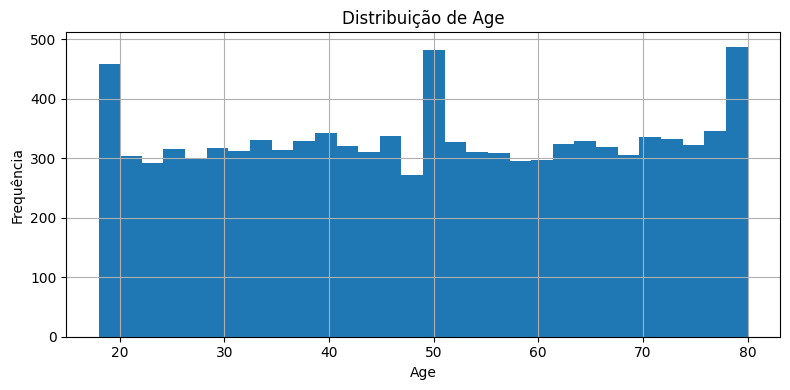

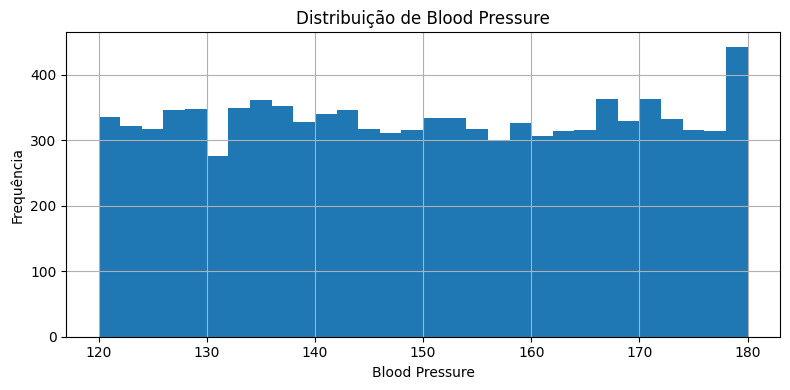

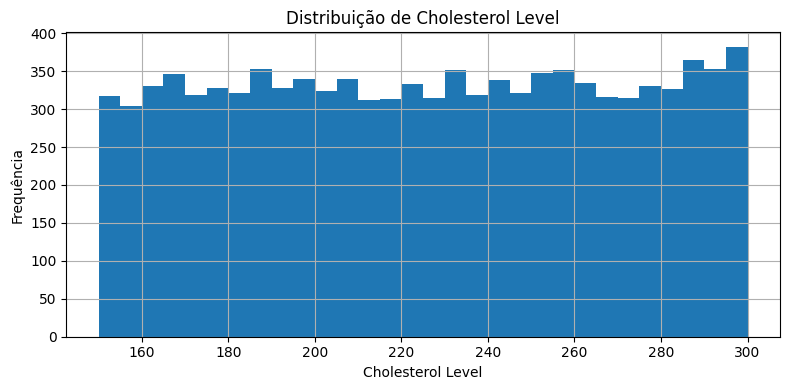

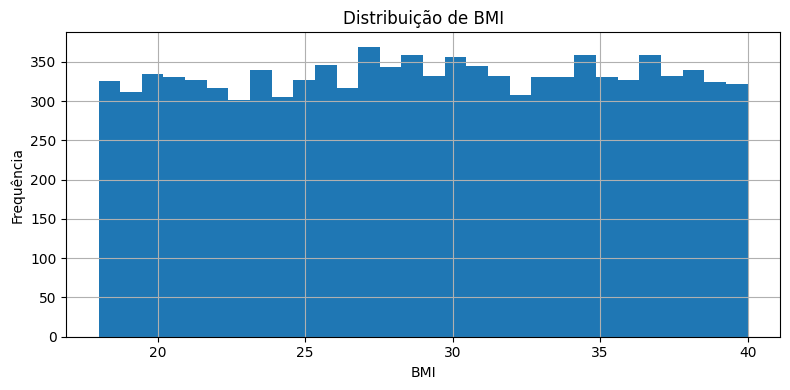

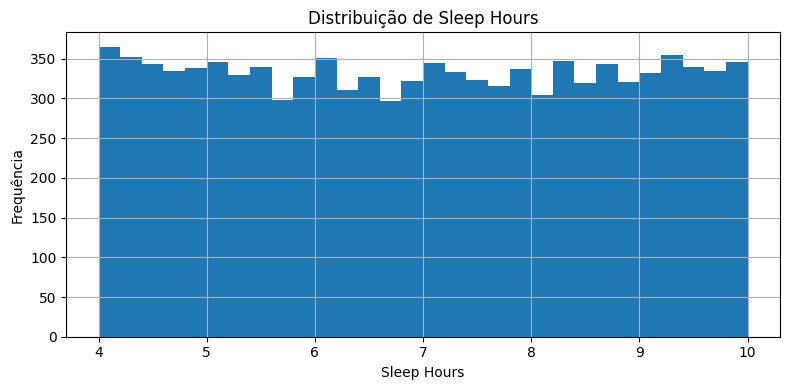

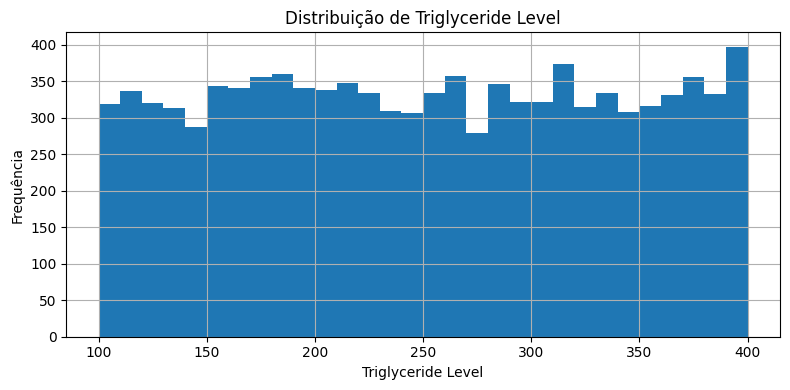

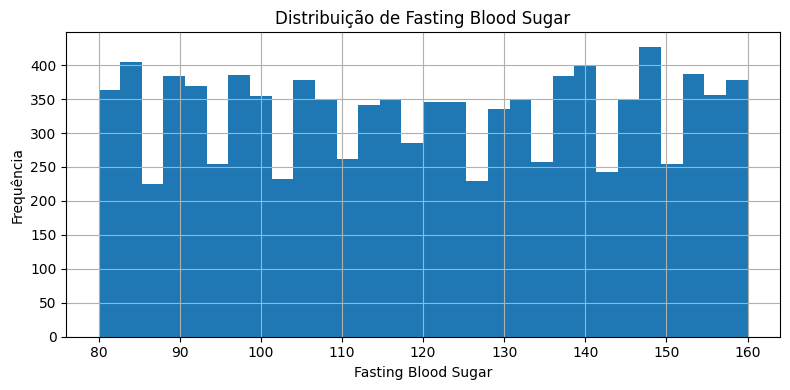

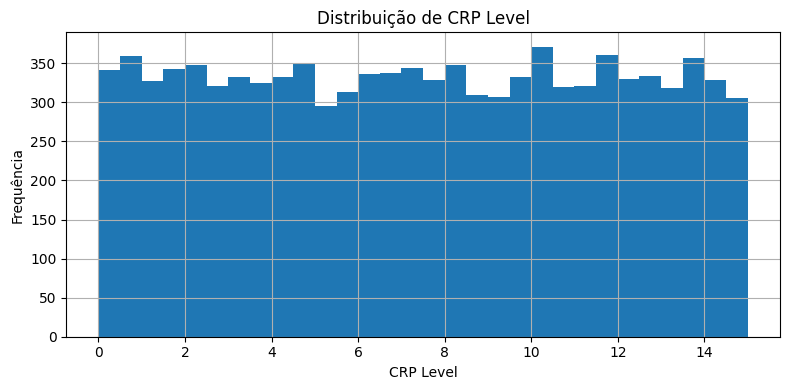

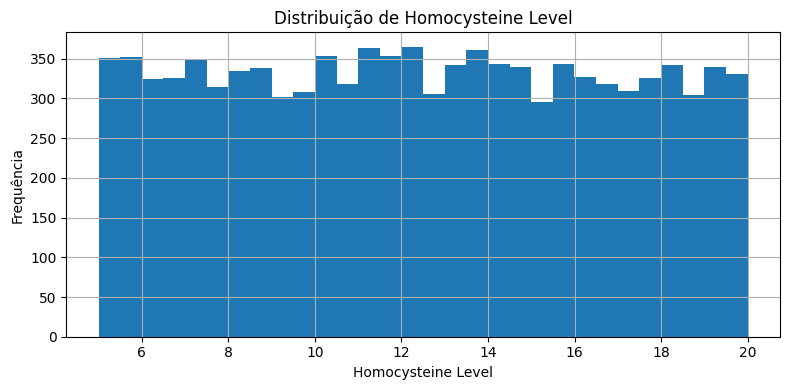

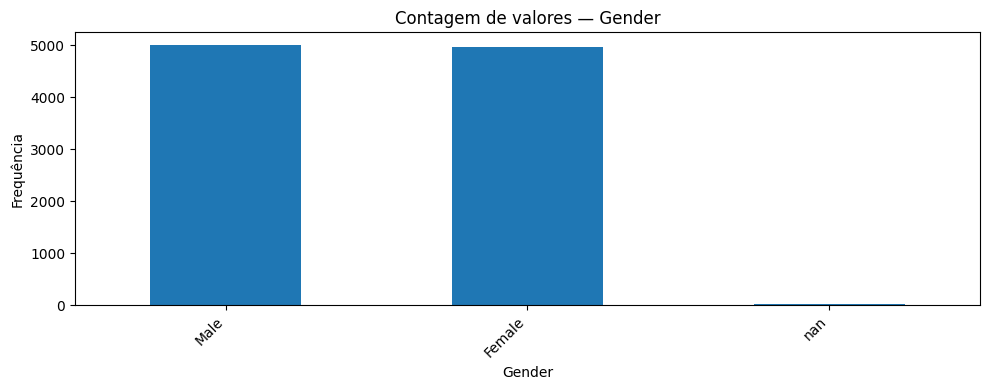

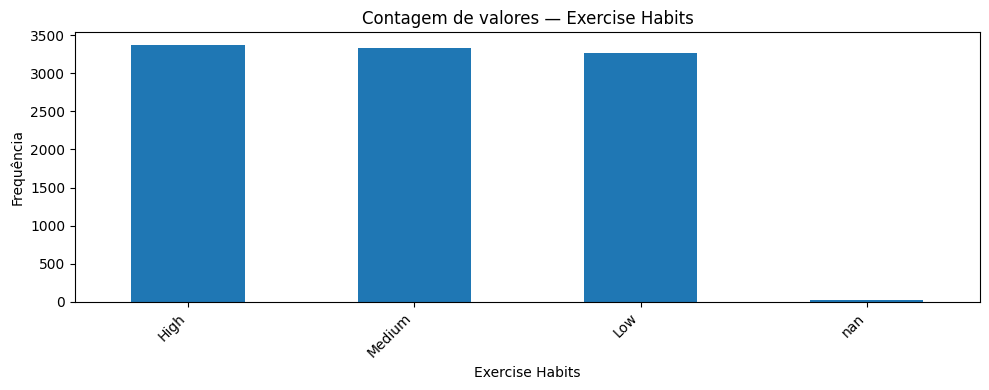

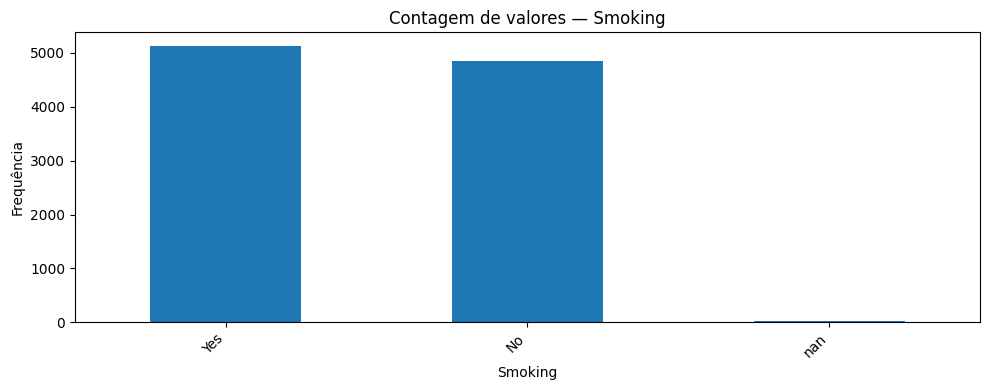

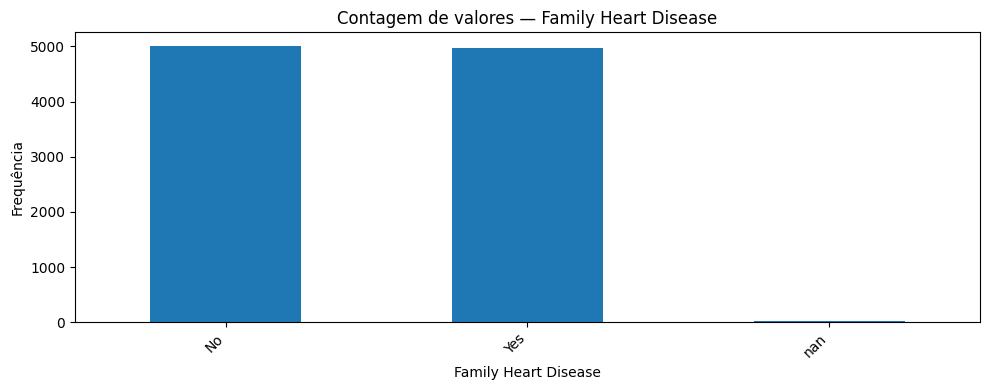

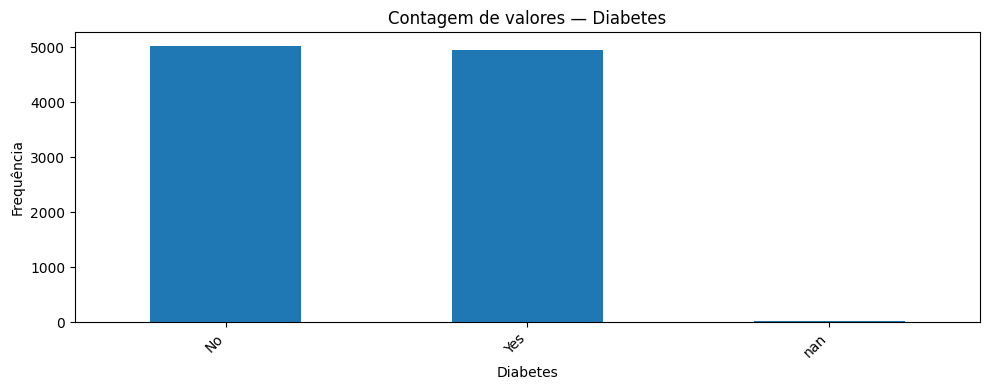

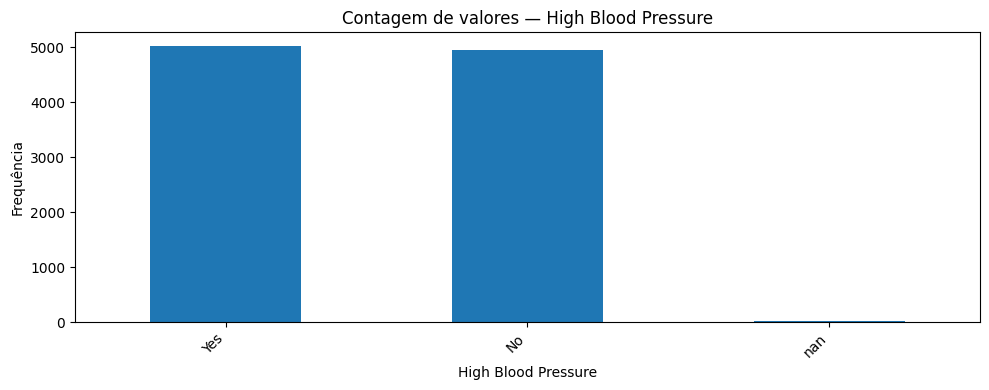

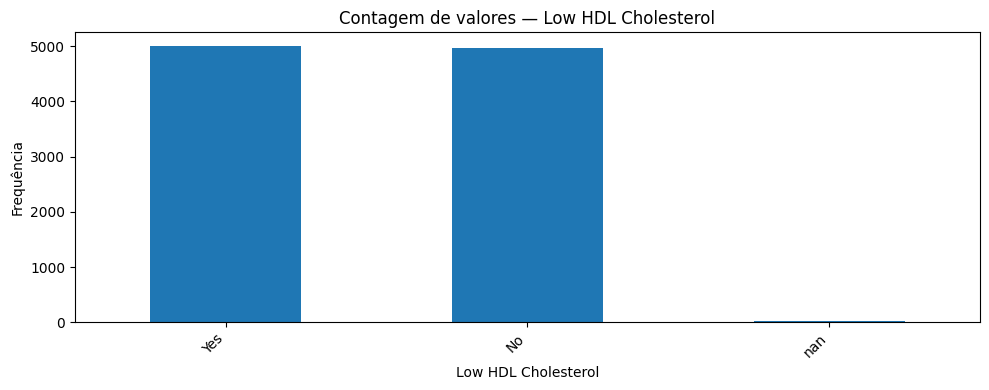

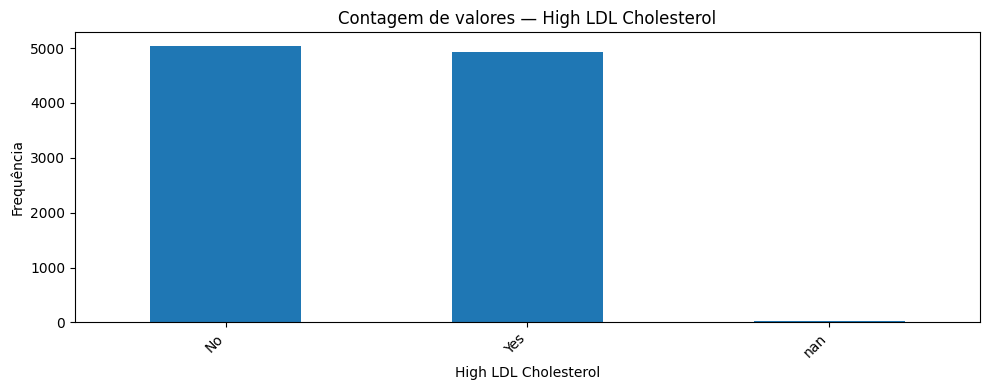

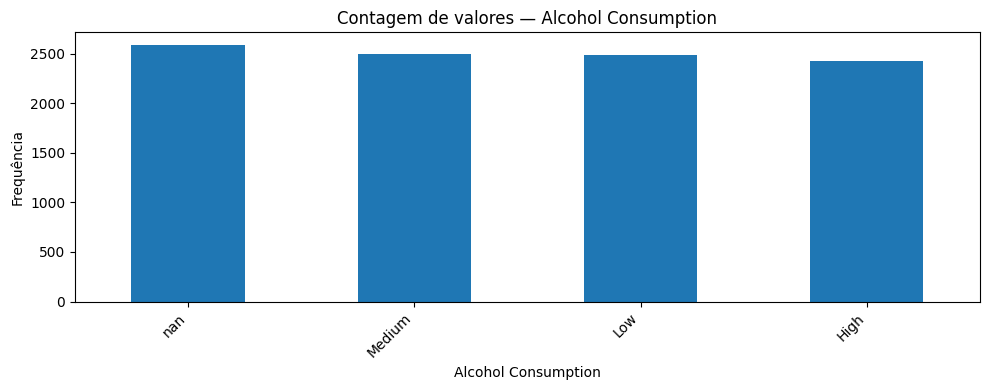

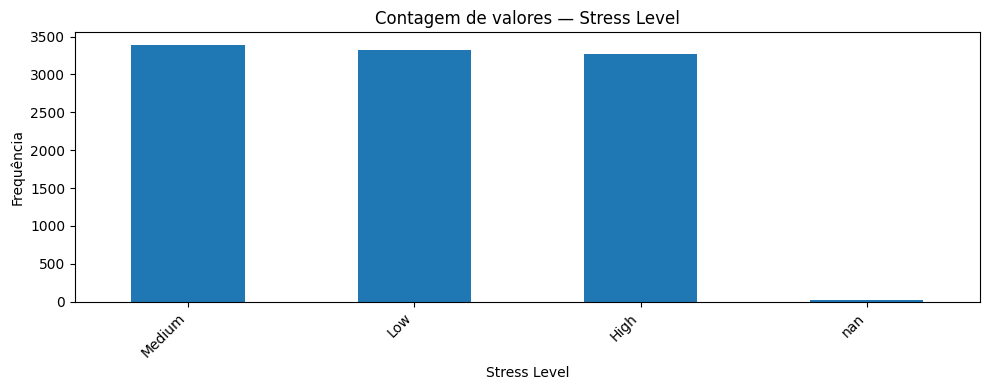

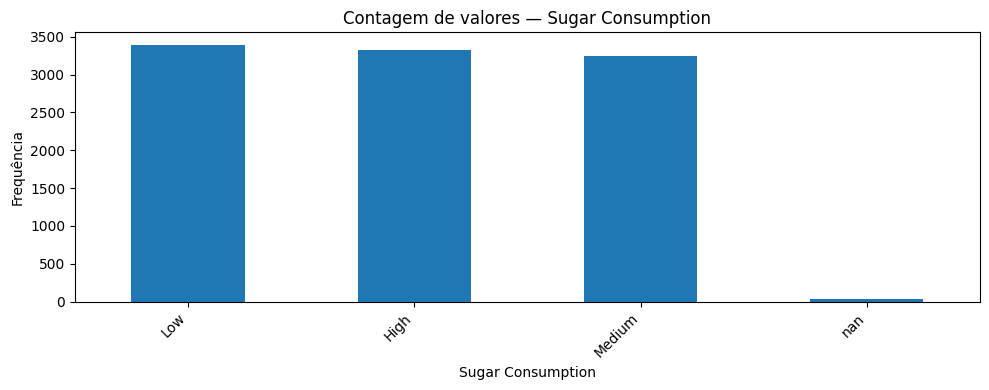

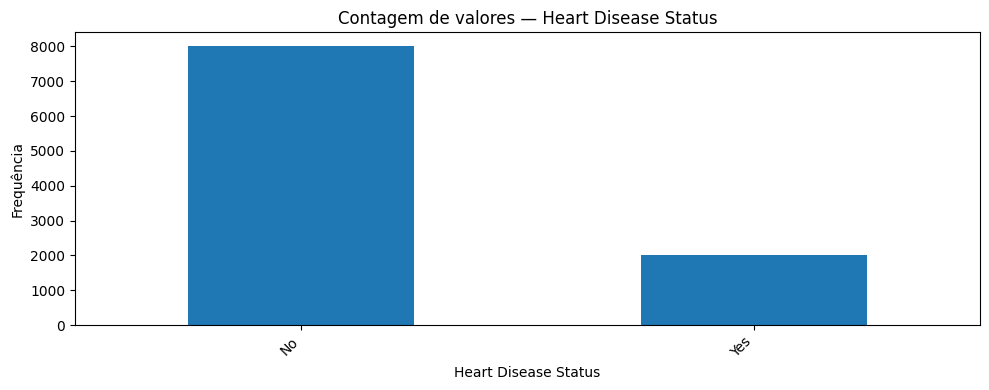

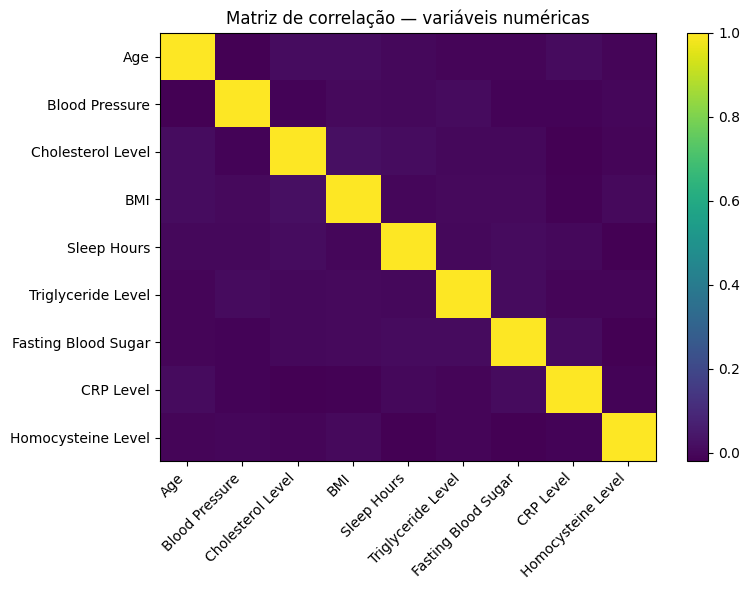

In [99]:
# Visualizações exploratórias básicas

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso: 
colunas_numericas = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
colunas_categoricas = ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']

for coluna in colunas_numericas:
    plot_distribuicao_numerica(df, coluna)

for coluna in colunas_categoricas:
    plot_contagem_categorica(df, coluna)

plot_matriz_correlacao(df)

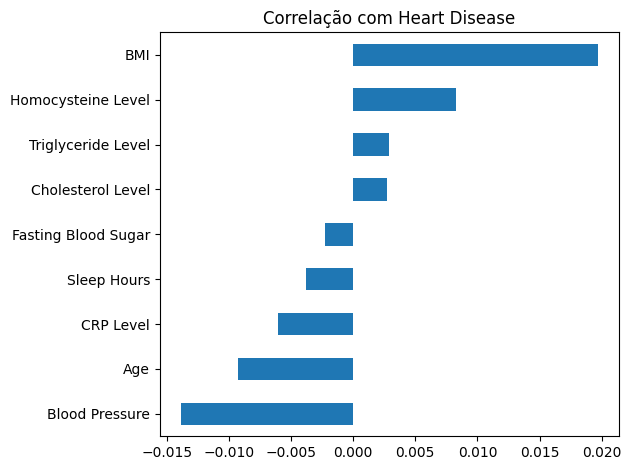

In [100]:
import matplotlib.pyplot as plt

df['Heart Disease Status Bin'] = df['Heart Disease Status'].map({'No': 0, 'Yes': 1})

corr_target = (
    df.corr(numeric_only=True)['Heart Disease Status Bin']
      .drop('Heart Disease Status Bin')
      .sort_values()
)

corr_target.plot(kind='barh')
plt.title('Correlação com Heart Disease')
plt.tight_layout()
plt.show()
df = df.drop(columns=["Heart Disease Status Bin"])

## 2.2 Análise visual — interpretação

A análise visual revelou alguns padrões relevantes para a etapa de mineração de dados. Inicialmente, a distribuição da variável-alvo indica um **desbalanceamento considerável entre as classes**, com aproximadamente 80% dos registros classificados como "No" e 20% como "Yes". Esse comportamento sugere que modelos avaliados apenas por acurácia podem apresentar resultados aparentemente elevados sem necessariamente identificar adequadamente os pacientes com doença cardíaca.

Outro aspecto importante é a presença de valores ausentes em diversos atributos. Embora a maioria das variáveis apresente menos de 1% de dados faltantes, a variável Alcohol Consumption possui cerca de 25,9% de valores nulos, representando uma limitação relevante do conjunto de dados. Esse padrão exige tratamento específico durante o pré-processamento para evitar perda excessiva de informações ou introdução de vieses nos modelos.

As distribuições das variáveis numéricas não evidenciaram a presença de valores extremos significativos, uma vez que os valores observados permanecem dentro dos intervalos esperados para cada atributo. Da mesma forma, as variáveis categóricas apresentaram distribuições relativamente equilibradas entre suas categorias, sem a ocorrência de categorias muito raras que pudessem comprometer a aprendizagem dos modelos

A matriz de correlação das variáveis numéricas mostrou coeficientes extremamente baixos entre os atributos, com valores próximos de zero em praticamente todos os casos. Isso indica ausência de correlações lineares significativas e sugere baixa multicolinearidade entre as variáveis. Do ponto de vista da modelagem, essa característica reduz a redundância entre atributos, mas também indica que dificilmente uma única variável será suficiente para explicar a ocorrência da doença.

A análise da correlação entre os atributos e a variável-alvo reforça essa observação. Todas as correlações encontradas apresentam magnitude muito pequena, inferior a 0,03 em valor absoluto. Embora variáveis como IMC (BMI), níveis de homocisteína e triglicerídeos tenham apresentado associação positiva com a presença de doença cardíaca, e pressão arterial e idade tenham apresentado associação negativa, essas relações são extremamente fracas. Dessa forma, os resultados sugerem que a classificação dependerá da combinação de múltiplos fatores e de possíveis relações não lineares entre os atributos.

Em relação às diretrizes escolhidas, a análise visual evidencia um risco diretamente associado ao **Monitoramento e Avaliação**, pois o desbalanceamento das classes pode induzir interpretações equivocadas caso sejam utilizadas métricas inadequadas. Isso reforça a necessidade de utilizar indicadores como sensibilidade, especificidade, F1-score, AUC-ROC e matriz de confusão durante a avaliação dos modelos.

Quanto à **Explicabilidade**, os gráficos indicam que as relações entre os atributos e a variável-alvo não são triviais nem fortemente lineares. Assim, torna-se importante empregar técnicas que permitam compreender como diferentes variáveis contribuem conjuntamente para as previsões, facilitando a interpretação dos resultados em um contexto clínico.


In [101]:
# Detecção simples de outliers em variáveis numéricas usando IQR

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers


for coluna in colunas_numericas:
    outliers = detectar_outliers_iqr(df, coluna)

Coluna: Age
Q1: 34.0
Q3: 65.0
IQR: 31.0
Limite inferior: -12.5
Limite superior: 111.5
Número de outliers: 0
Coluna: Blood Pressure
Q1: 134.0
Q3: 165.0
IQR: 31.0
Limite inferior: 87.5
Limite superior: 211.5
Número de outliers: 0
Coluna: Cholesterol Level
Q1: 187.0
Q3: 263.0
IQR: 76.0
Limite inferior: 73.0
Limite superior: 377.0
Número de outliers: 0
Coluna: BMI
Q1: 23.658075171017085
Q3: 34.5200150669223
IQR: 10.861939895905213
Limite inferior: 7.365165327159264
Limite superior: 50.81292491078012
Número de outliers: 0
Coluna: Sleep Hours
Q1: 5.4498662242463265
Q3: 8.531577207989777
IQR: 3.0817109837434504
Limite inferior: 0.8272997486311509
Limite superior: 13.154143683604953
Número de outliers: 0
Coluna: Triglyceride Level
Q1: 176.0
Q3: 326.0
IQR: 150.0
Limite inferior: -49.0
Limite superior: 551.0
Número de outliers: 0
Coluna: Fasting Blood Sugar
Q1: 99.0
Q3: 141.0
IQR: 42.0
Limite inferior: 36.0
Limite superior: 204.0
Número de outliers: 0
Coluna: CRP Level
Q1: 3.674126239210254
Q3: 

In [102]:
#Verificação de duplicatas
duplicatas = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicatas}")

Número de linhas duplicadas: 0


## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em Alcohol Consumption | 2.586 valores nulos (25,86% dos registros)| Imputar valores faltantes com a moda | A variável apresenta uma quantidade significativa de valores ausentes. A imputação evita a perda de aproximadamente um quarto do conjunto de dados. |
| Valores ausentes nas demais variáveis | Menos de 1% de valores ausentes em cada atributo| Imputar valores faltantes com a mediana para atributos numéricos e com a moda para atributos categóricos| O baixo percentual de ausência permite o tratamento sem impacto significativo na distribuição dos dados. |
| Duplicatas | Verificação dos registros não identificou linhas duplicadas (df.duplicated().sum() = 0) | Nenhuma ação necessária | Não há registros repetidos que possam introduzir viés ou redundância na análise. |
| Outliers | Análise visual e estatísticas descritivas não identificaram valores extremos relevantes| Nenhuma ação necessária | Os valores observados encontram-se dentro dos intervalos esperados para cada atributo. |
| Categorias raras | As frequências das categorias mostraram distribuição relativamente equilibrada entre os níveis das variáveis categóricas| Nenhuma ação necessária| Não foram observadas categorias com frequência muito baixa que justificassem agrupamento ou remoção. |
| Atributos sensíveis (Age e Gender) | Variáveis demográficas presentes no conjunto de dados |Manter os atributos| São fatores potencialmente relevantes para a predição de doenças cardiovasculares e para a interpretação clínica dos resultados. |
| Identificadores | Não foram identificadas colunas com identificadores únicos ou informações pessoais | Nenhuma ação necessária| Não há evidências de risco de vazamento de informação por identificadores. |

### Observação sobre responsabilidade

As decisões de preparação dos dados possuem impacto direto sobre as diretrizes de **Monitoramento e Avaliação** e **Explicabilidade** adotadas neste trabalho. A imputação dos valores ausentes foi escolhida para preservar a quantidade de registros disponíveis para treinamento e avaliação dos modelos, reduzindo o risco de perda de informações relevantes. Essa decisão contribui para que as métricas calculadas durante a avaliação representem melhor o comportamento esperado dos modelos.

Além disso, optou-se por manter os atributos **Age** e **Gender**, pois são variáveis potencialmente relevantes para a predição de doenças cardiovasculares e possuem significado clínico bem estabelecido. Essa escolha favorece a **Explicabilidade**, uma vez que permite relacionar as previsões dos modelos a fatores de risco conhecidos pelos profissionais da saúde. 

Por fim, o desbalanceamento observado na variável-alvo reforça a importância da diretriz de **Monitoramento e Avaliação**, tornando necessária a utilização de métricas além da acurácia, como sensibilidade, especificidade, F1-score e AUC-ROC, para avaliar corretamente a capacidade dos modelos em identificar pacientes com doença cardíaca.

In [103]:
# Preparação dos dados

import pandas as pd
import numpy as np

# Preparação dos dados

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def preparar_dados(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preparação do dataset Heart Disease.
    - Imputação de valores ausentes.
    - Label Encoding
    - One-Hot Encoding das variáveis categóricas.
    - Normalização Min-Max das variáveis numéricas.
    """

    df_prep = df.copy()

    # 1. Tratamento de nulos

    colunas_numericas = df_prep.select_dtypes(include=np.number).columns

    for col in colunas_numericas:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    colunas_categoricas = df_prep.select_dtypes(
        include=["object", "category"]
    ).columns

    for col in colunas_categoricas:
        moda = df_prep[col].mode()[0]
        df_prep[col] = df_prep[col].fillna(moda)


    # 2. Variáveis binárias (Converter No/Yes para 0/1)

    colunas_binarias = [
        'Smoking',
        'Family Heart Disease',
        'Diabetes',
        'High Blood Pressure',
        'Low HDL Cholesterol',
        'High LDL Cholesterol',
        'Heart Disease Status'
    ]

    for col in colunas_binarias:
        df_prep[col] = df_prep[col].map({
            'No': 0,
            'Yes': 1
        })

    # Gender também é binária
    df_prep['Gender'] = df_prep['Gender'].map({
        'Female': 0,
        'Male': 1
    })

    # 3. One-Hot Encoding

    colunas_multiclasse = [
        'Exercise Habits',
        'Alcohol Consumption',
        'Stress Level',
        'Sugar Consumption'
    ]

    df_prep = pd.get_dummies(
        df_prep,
        columns=colunas_multiclasse,
        drop_first=True,
        dtype=int
    )

    # 4. Normalização

    colunas_numericas = [
        'Age',
        'Blood Pressure',
        'Cholesterol Level',
        'BMI',
        'Sleep Hours',
        'Triglyceride Level',
        'Fasting Blood Sugar',
        'CRP Level',
        'Homocysteine Level'
    ]

    scaler = MinMaxScaler()

    df_prep[colunas_numericas] = scaler.fit_transform(
        df_prep[colunas_numericas]
    )

    return df_prep


df_prep = preparar_dados(df)

print(df_prep.shape)
display(df_prep.head())

(10000, 25)


,Age,Gender,Blood Pressure,Cholesterol Level,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,...,Homocysteine Level,Heart Disease Status,Exercise Habits_Low,Exercise Habits_Medium,Alcohol Consumption_Low,Alcohol Consumption_Medium,Stress Level_Low,Stress Level_Medium,Sugar Consumption_Low,Sugar Consumption_Medium
0,0.612903,1,0.550000,0.033333,1,1,0,0.317756,1,1,...,0.492507,0,0,0,0,0,0,1,0,1
1,0.822581,0,0.433333,0.906667,0,1,1,0.328222,0,1,...,0.953319,0,0,0,0,1,0,0,0,1
2,0.451613,1,0.100000,0.440000,0,0,0,0.538899,0,1,...,0.415412,0,1,0,1,0,1,0,1,0
3,0.225806,0,0.033333,0.953333,1,1,0,0.278604,1,0,...,0.064120,0,0,0,1,0,0,0,0,0
4,0.677419,1,0.766667,0.613333,1,1,1,0.112914,1,0,...,0.210260,0,1,0,1,0,0,0,0,0


In [104]:
df_prep.columns.tolist()

['Age',
 'Gender',
 'Blood Pressure',
 'Cholesterol Level',
 'Smoking',
 'Family Heart Disease',
 'Diabetes',
 'BMI',
 'High Blood Pressure',
 'Low HDL Cholesterol',
 'High LDL Cholesterol',
 'Sleep Hours',
 'Triglyceride Level',
 'Fasting Blood Sugar',
 'CRP Level',
 'Homocysteine Level',
 'Heart Disease Status',
 'Exercise Habits_Low',
 'Exercise Habits_Medium',
 'Alcohol Consumption_Low',
 'Alcohol Consumption_Medium',
 'Stress Level_Low',
 'Stress Level_Medium',
 'Sugar Consumption_Low',
 'Sugar Consumption_Medium']

## 2.4 Justificativa da preparação dos dados

Nenhuma coluna foi removida durante a etapa de preparação, pois não foram identificados atributos que atuassem como identificadores únicos ou que fossem considerados irrelevantes para a tarefa de classificação. A manutenção de todos os atributos preserva a maior quantidade possível de informação potencialmente útil para a predição da presença de doença cardíaca.

Os valores ausentes foram tratados por meio de imputação. Para as variáveis numéricas, foi utilizada a mediana, enquanto para as variáveis categóricas foi utilizada a moda. A escolha da mediana para atributos numéricos deve-se à sua robustez em relação a distribuições assimétricas, enquanto a moda preserva a categoria mais representativa nas variáveis categóricas. Essa estratégia foi adotada para evitar a perda de registros, especialmente considerando que a variável Alcohol Consumption apresenta aproximadamente 25,9% de valores ausentes.

As variáveis categóricas binárias (Smoking, Family Heart Disease, Diabetes, High Blood Pressure, Low HDL Cholesterol, High LDL Cholesterol, Gender e Heart Disease Status) foram convertidas para representação numérica binária (0 e 1). Já as variáveis categóricas com mais de duas categorias (Exercise Habits, Alcohol Consumption, Stress Level e Sugar Consumption) foram transformadas por meio de One-Hot Encoding, criando variáveis indicadoras para cada categoria. Essa abordagem evita a introdução de relações ordinais artificiais entre categorias que não possuem ordenação natural.

As variáveis numéricas foram normalizadas utilizando a técnica Min-Max Scaling, que transforma os valores para o intervalo [0,1]. Essa etapa foi considerada importante porque os atributos apresentam escalas bastante distintas. Por exemplo, variáveis como colesterol e triglicerídeos possuem amplitudes muito superiores às observadas para horas de sono ou níveis de CRP. A normalização reduz o impacto dessas diferenças de escala, tornando os atributos comparáveis e favorecendo o desempenho de algoritmos sensíveis à distância.

Não foi realizada remoção de outliers, pois as análises exploratórias e estatísticas descritivas não identificaram valores extremos relevantes que justificassem sua exclusão. Da mesma forma, não foram encontradas duplicatas no conjunto de dados.

As decisões adotadas apresentam alguns riscos. A imputação de valores ausentes pode introduzir viés ao substituir observações desconhecidas por valores representativos da população. Além disso, a normalização altera a escala original dos atributos, o que pode dificultar a interpretação direta dos valores. Entretanto, essas limitações são compensadas pelos benefícios obtidos em termos de preservação da amostra, padronização dos atributos e adequação dos dados aos algoritmos utilizados. A imputação dos valores ausentes evita a perda de registros e mantém a quantidade de exemplos disponíveis para treinamento e avaliação dos modelos. O One-Hot Encoding permite representar corretamente as variáveis categóricas sem introduzir relações ordinais artificiais entre categorias. Já a normalização Min-Max reduz as diferenças de escala entre os atributos, sendo especialmente importante para algoritmos baseados em distância ou geometria dos dados, como o K-Nearest Neighbors (KNN) e o Support Vector Machine (SVM). Embora algoritmos como Decision Trees e Naive Bayes sejam menos sensíveis à escala dos atributos, a utilização de uma única estratégia de preparação torna o conjunto de dados consistente para todos os modelos avaliados e facilita a comparação dos resultados durante o processo de monitoramento e avaliação.

Essas escolhas estão diretamente relacionadas às diretrizes de Monitoramento e Avaliação e Explicabilidade. A imputação dos valores ausentes e a preservação dos registros contribuem para uma avaliação mais estável e representativa dos modelos. Já a codificação das variáveis categóricas e a manutenção de atributos clinicamente relevantes favorecem a interpretabilidade dos resultados, permitindo compreender de forma mais clara a contribuição dos diferentes fatores de risco para a predição da doença cardíaca.


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração.

---

### Trilha A — baseline

**Modelo utilizado:** Gemini PRO 

**Data de acesso:** 07/06/2026

**Link da conversa:** https://gemini.google.com/share/ff697b4549d3 

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com esse dataset 'Heart Disease Dataset'.

A tarefa de mineração é classificação.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar

os dados para essa tarefa. 
```

#### Síntese da resposta da LLM

A LLM sugeriu um fluxo padrão de pré-processamento para problemas de classificação médica:

- Explorar os dados por meio de estatísticas descritivas, distribuição das variáveis, análise da variável-alvo, correlações entre atributos e identificação de possíveis outliers.
- Verificar desbalanceamento da variável-alvo, pois isso pode prejudicar o aprendizado dos modelos.
- Tratar valores ausentes utilizando imputação (mediana para variáveis numéricas e moda para categóricas).
- Codificar variáveis categóricas, usando representação binária (0 e 1) para variáveis com duas categorias e One-Hot Encoding para variáveis com múltiplas categorias.
- Normalizar ou padronizar as variáveis numéricas para evitar que diferenças de escala influenciem algoritmos como KNN e SVM.
- Investigar multicolinearidade, removendo atributos redundantes quando necessário.
- Avaliar a necessidade de tratar o desbalanceamento das classes, por exemplo utilizando técnicas como SMOTE nos dados de treinamento.
- Ter cautela com outliers, pois em dados médicos valores extremos podem representar condições clínicas reais e não necessariamente erros.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini PRO 

**Data de acesso:** 07/06/2026

**Link da conversa:** https://gemini.google.com/share/2911ed7a1007 

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com esse dataset 'Heart Disease Dataset'.

A tarefa de mineração é classificação.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar

os dados para essa tarefa. 

Considere explicitamente as seguintes diretrizes de IA responsável:

1. Monitoramento e Avaliação: Em problemas de classificação médica, avaliar corretamente os modelos é essencial, principalmente para evitar falsos negativos (classificar pacientes doentes como saudáveis).

2. Explicabilidade: Modelos aplicados à área da saúde precisam apresentar transparência, permitindo compreender claramente quais fatores estão associados ao risco cardiovascular. 

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis, se houver;
- riscos de viés ou perda de informação;
- decisões que devem ser documentadas;
- transformações necessárias;
- limitações e trade-offs.
```

#### Síntese da resposta da LLM

A IA destacou que, em problemas de saúde, a análise dos dados deve considerar não apenas aspectos estatísticos, mas também riscos éticos e de viés. Ela chamou atenção para os atributos sensíveis Age e Gender, que podem influenciar injustamente as previsões do modelo, além da diferença entre variáveis clínicas objetivas e variáveis comportamentais autorrelatadas, que podem conter vieses.

Na etapa de preparação dos dados, recomendou tratar cuidadosamente os valores ausentes, avaliar possíveis redundâncias entre atributos por meio da análise de correlação, converter variáveis categóricas para formato numérico e normalizar atributos com escalas diferentes. Também destacou a importância de lidar com o desbalanceamento das classes para reduzir o risco de falsos negativos em pacientes com doença cardíaca.

Por fim, enfatizou que toda transformação realizada deve ser documentada, incluindo tratamento de valores ausentes, remoção de variáveis redundantes e tratamento de outliers. A IA também alertou para os trade-offs entre desempenho e interpretabilidade, recomendando evitar técnicas como PCA quando a explicabilidade for uma das principais diretrizes do projeto.


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Imputar valores numéricos pela mediana e categóricos pela moda e considerar remoção de linhas com muitos nulos | Destacou que a ausência de dados pode ter significado clínico e que a imputação deve ser feita com cautela | ACEITAR PARCIALMENTE. Foi realizada imputação por mediana (numéricos) e moda (categóricos), preservando todos os registros. |
| Tratamento de outliers | Identificar por boxplots e avaliar antes de remover, alertando que valores extremos podem representar condições clínicas reais e não erros | Idem | ACEITAR. Todavia, não foram encontrados outliers relevantes na nossa base de dados que justificassem remoção. |
| Atributos sensíveis | Pouca discussão sobre impacto ético | Destacou Age e Gender como atributos sensíveis e potenciais fontes de viés | ACEITAR. Os atributos foram mantidos, mas seu impacto será monitorado durante a avaliação dos modelos. |
| Codificação de variáveis | Label Encoding para variáveis binárias e One-Hot Encoding para variáveis multicategoriais | Recomendou codificação simples e interpretável, como One-Hot Encoding | ACEITAR. Variáveis binárias foram convertidas para 0/1 e variáveis multicategoriais codificadas com One-Hot Encoding. |
| Redução de dimensionalidade | Sugeriu investigar multicolinearidade e remover atributos redundantes| Recomendou evitar PCA devido à perda de interpretabilidade | ACEITAR PARCIALMENTE. Não foram encontradas correlações fortes que justificassem remoção de atributos, e PCA não foi utilizado devido à diretriz de explicabilidade. |
| Justificativa técnica | Foco em qualidade dos dados e adequação aos algoritmos| Foco em interpretabilidade, riscos de viés e documentação das decisões | As duas abordagens foram utilizadas para fundamentar as decisões adotadas. |
| Riscos e limitações | Destacou desbalanceamento, valores ausentes e escalas diferentes | Destacou desbalanceamento, vieses, perda de explicabilidade e riscos de tratamento inadequado dos dados médicos | Os riscos identificados por ambas as trilhas foram considerados na preparação dos dados.|

### Análise crítica

A **Trilha A** apresentou recomendações tecnicamente corretas para as etapas de compreensão e preparação dos dados. Foram sugeridas análises exploratórias, tratamento de valores ausentes, codificação de variáveis categóricas, normalização dos atributos e avaliação do desbalanceamento da variável-alvo. Essas recomendações estão de acordo com as boas práticas de mineração de dados e foram aceitas pelo grupo. Em particular, foram implementadas a imputação de valores ausentes, a codificação das variáveis categóricas e a normalização das variáveis numéricas.

A **Trilha B** também apresentou sugestões tecnicamente corretas, porém com maior foco nas diretrizes de **Monitoramento e Avaliação** e **Explicabilidade**. A identificação de **Age** e **Gender** como atributos sensíveis foi considerada adequada, assim como o alerta de que valores extremos em dados médicos podem representar condições clínicas reais e não necessariamente erros. Essas observações contribuíram para uma análise mais cuidadosa dos dados e para a documentação das decisões adotadas.

Algumas recomendações de ambas as trilhas estavam incompletas por não considerarem as características específicas do conjunto de dados analisado. Por exemplo, as duas trilhas sugeriram investigar possíveis problemas de multicolinearidade entre variáveis cardiovasculares e considerar a remoção de atributos redundantes. Entretanto, após o cálculo da matriz de correlação, não foram observadas correlações suficientemente fortes para justificar a exclusão de variáveis. Dessa forma, a recomendação foi corrigida pelo grupo com base na evidência empírica obtida.

Também foi sugerida a utilização de técnicas de balanceamento, como SMOTE, devido ao desbalanceamento existente na variável-alvo. Embora a recomendação seja tecnicamente válida, sua aplicação depende da etapa de modelagem. Por esse motivo, o grupo optou por não aplicá-la durante a preparação dos dados, deixando essa decisão para a fase posterior.

Nenhuma das trilhas apresentou erros técnicos graves. No entanto, algumas hipóteses levantadas pelas LLMs não foram confirmadas pelos dados analisados. A possibilidade de forte multicolinearidade entre atributos cardiovasculares e a necessidade de remoção de outliers não encontraram suporte nas análises realizadas. Por isso, essas sugestões foram corrigidas pelo grupo.

Em síntese, foram aceitas as recomendações relacionadas ao tratamento de valores ausentes, codificação das variáveis categóricas, normalização dos atributos e atenção ao desbalanceamento das classes. Foram rejeitadas as sugestões de remoção de atributos por multicolinearidade e exclusão de outliers, uma vez que as evidências obtidas durante a análise exploratória não justificaram tais intervenções. A principal contribuição adicional da Trilha B foi incorporar uma discussão mais aprofundada sobre transparência, atributos sensíveis e possíveis vieses, aspectos diretamente relacionados às diretrizes de **Monitoramento e Avaliação** e **Explicabilidade** adotadas no projeto.

# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** [EXEMPLO: propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa]

---

### Trilha A — baseline

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — baseline

```text
[INSERIR PROMPT BASELINE]

Exemplo:
Com base no dataset [NOME] e na tarefa [TAREFA], proponha uma estratégia de modelagem.
Indique algoritmos, parâmetros iniciais, métricas de avaliação e como comparar resultados.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — guiado

```text
[INSERIR PROMPT GUIADO]

Exemplo:
Com base no dataset [NOME] e na tarefa [TAREFA], proponha uma estratégia de modelagem.

Considere explicitamente as diretrizes:
1. [DIRETRIZ 1]
2. [DIRETRIZ 2]

Na resposta, indique:
- algoritmos adequados;
- parâmetros iniciais;
- métricas de avaliação;
- riscos metodológicos;
- impacto das diretrizes nas escolhas;
- trade-offs entre desempenho, interpretabilidade, custo computacional e qualidade da solução.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]


## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Parâmetros sugeridos | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Métricas sugeridas | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Preparação exigida | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Interpretabilidade | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Custo computacional | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Riscos ou limitações | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |
| Aderência às diretrizes | [PREENCHER] | [PREENCHER] | [SIM/NÃO] | [ANALISAR] |

### Síntese

[INSERIR ANÁLISE COMPARATIVA]

A comparação deve destacar evidências, não impressões vagas.


## 3.3 Template de modelagem para padrões frequentes

Use esta subseção se o TP atual envolver mineração de padrões frequentes. Caso o TP atual seja de agrupamento ou classificação, esta subseção pode ser removida ou mantida como referência não executada.

> **Atenção:** suporte, confiança e lift devem ser interpretados no contexto do dataset. Valores de suporte muito baixos podem gerar muitas regras pouco úteis; valores muito altos podem ocultar padrões relevantes.


In [ ]:
# Exemplo de preparação para mineração de padrões frequentes
# Use esta célula apenas se o TP atual for de padrões frequentes.
# Para classificação ou agrupamento, substituir por uma preparação adequada.

def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> list:
    # Gera uma lista de transações a partir de uma coluna textual.
    # Exemplo: "leite, pão, manteiga" -> ["leite", "pão", "manteiga"]
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [
            item.strip().lower()
            for item in str(valor).split(separador)
            if item.strip()
        ]

        if len(itens) > 0:
            transacoes.append(itens)

    return transacoes

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# print(f"Número de transações: {len(transacoes)}")
# print(transacoes[:5])


In [ ]:
# Exemplo de execução de Apriori e FP-Growth com mlxtend
# Esta célula é semi-funcional e depende da instalação da biblioteca mlxtend.
# O grupo deve ajustar suporte, confiança e métrica conforme o problema.

def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada.")
        print("Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(
        df_transacoes,
        min_support=min_support,
        use_colnames=True
    )
    regras_apriori = association_rules(
        itemsets_apriori,
        metric="confidence",
        min_threshold=min_confidence
    )
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(
        df_transacoes,
        min_support=min_support,
        use_colnames=True
    )
    regras_fpgrowth = association_rules(
        itemsets_fpgrowth,
        metric="confidence",
        min_threshold=min_confidence
    )
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo": tempo_fpgrowth
    }

    return resultados

# Exemplo de uso:
# resultados = executar_padroes_frequentes(
#     transacoes,
#     min_support=0.05,
#     min_confidence=0.6
# )


In [ ]:
# Resumo dos resultados de mineração de padrões frequentes.
# Esta célula não inventa resultados; ela apenas resume o que foi executado.

def resumir_resultados_padroes(resultados):
    if resultados is None:
        print("Nenhum resultado disponível.")
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo"], 4),
            "suporte_minimo_observado": itemsets["support"].min() if len(itemsets) > 0 else np.nan,
            "suporte_maximo_observado": itemsets["support"].max() if len(itemsets) > 0 else np.nan,
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# resumo_modelagem = resumir_resultados_padroes(resultados)
# display(resumo_modelagem)


In [ ]:
# Exemplo de variação de parâmetros
# Útil para verificar se os resultados são sensíveis às escolhas de suporte e confiança.

def testar_parametros_padroes(transacoes, suportes, confiancas):
    linhas = []

    for sup in suportes:
        for conf in confiancas:
            resultados = executar_padroes_frequentes(
                transacoes,
                min_support=sup,
                min_confidence=conf
            )

            resumo = resumir_resultados_padroes(resultados)

            if not resumo.empty:
                resumo["min_support"] = sup
                resumo["min_confidence"] = conf
                linhas.append(resumo)

    if len(linhas) == 0:
        return pd.DataFrame()

    return pd.concat(linhas, ignore_index=True)

# Exemplo de uso:
# grade_resultados = testar_parametros_padroes(
#     transacoes,
#     suportes=[0.01, 0.03, 0.05],
#     confiancas=[0.5, 0.6, 0.7]
# )
# display(grade_resultados)


## 3.4 Template de modelagem para agrupamento

Use esta subseção se o TP atual envolver agrupamento. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em agrupamento, não há rótulo verdadeiro na maioria dos casos. A avaliação deve combinar métricas internas, análise visual quando possível e interpretação substantiva dos grupos.


In [ ]:
# Exemplo genérico para agrupamento com K-Means
# O grupo deve adaptar features, normalização e métricas conforme o dataset.

def preparar_matriz_numerica_para_modelagem(df: pd.DataFrame, colunas=None) -> pd.DataFrame:
    if colunas is None:
        X = df.select_dtypes(include=np.number).copy()
    else:
        X = df[colunas].copy()

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    return X

def executar_kmeans_basico(X: pd.DataFrame, n_clusters=3):
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans
        from sklearn.metrics import silhouette_score, davies_bouldin_score
    except ImportError:
        print("Biblioteca scikit-learn não instalada.")
        return None

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    modelo = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = modelo.fit_predict(X_scaled)

    resultados = {
        "modelo": modelo,
        "labels": labels,
        "silhouette": silhouette_score(X_scaled, labels) if n_clusters > 1 else np.nan,
        "davies_bouldin": davies_bouldin_score(X_scaled, labels) if n_clusters > 1 else np.nan,
        "inertia": modelo.inertia_
    }

    return resultados

# Exemplo de uso:
# X = preparar_matriz_numerica_para_modelagem(df_prep)
# resultados_cluster = executar_kmeans_basico(X, n_clusters=3)
# resultados_cluster


## 3.5 Template de modelagem para classificação

Use esta subseção se o TP atual envolver classificação. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em classificação, é importante discutir divisão treino/teste, validação, desbalanceamento de classes e escolha de métricas. Acurácia isolada pode ser inadequada em bases desbalanceadas.


In [ ]:
# Exemplo genérico para classificação
# O grupo deve adaptar TARGET_COLUMN, tratamento de categóricas e métricas.

def executar_classificacao_basica(df: pd.DataFrame, target_col: str):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.pipeline import Pipeline
        from sklearn.compose import ColumnTransformer
        from sklearn.preprocessing import OneHotEncoder, StandardScaler
        from sklearn.impute import SimpleImputer
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import classification_report, confusion_matrix
    except ImportError:
        print("Biblioteca scikit-learn não instalada.")
        return None

    if target_col not in df.columns:
        raise ValueError(f"Coluna-alvo não encontrada: {target_col}")

    X = df.drop(columns=[target_col])
    y = df[target_col]

    colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
    colunas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    preprocessador = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), colunas_numericas),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), colunas_categoricas)
        ]
    )

    modelo = Pipeline([
        ("preprocessamento", preprocessador),
        ("classificador", RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    inicio = time.time()
    modelo.fit(X_train, y_train)
    tempo_treino = time.time() - inicio

    y_pred = modelo.predict(X_test)

    print(f"Tempo de treino: {tempo_treino:.4f} segundos")
    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred))

    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "modelo": modelo,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "tempo_treino": tempo_treino
    }

# Exemplo de uso:
# resultados_classificacao = executar_classificacao_basica(df_prep, TARGET_COLUMN)


## 3.6 Resultados preliminares da modelagem

[INSERIR RESULTADOS OBTIDOS APÓS EXECUÇÃO DO CÓDIGO]

Inclua tabelas e comentários sobre os resultados relevantes para a tarefa:

### Se a tarefa for padrões frequentes

- número de padrões encontrados;
- número de regras geradas;
- suporte, confiança e lift;
- tempo de execução;
- redundância e interpretabilidade das regras.

### Se a tarefa for agrupamento

- número de clusters;
- métricas internas, como Silhouette e Davies-Bouldin;
- tamanho dos grupos;
- interpretação dos clusters;
- estabilidade com diferentes parâmetros.

### Se a tarefa for classificação

- métricas como acurácia, precisão, revocação, F1-score e matriz de confusão;
- análise de classes minoritárias;
- overfitting ou underfitting;
- interpretabilidade e possíveis vieses.

### Atenção

Não conclua que um algoritmo é “melhor” apenas por uma métrica isolada.

Uma comparação adequada deve considerar:

- qualidade da solução;
- interpretabilidade;
- custo computacional;
- estabilidade;
- adequação ao problema;
- relação com as diretrizes escolhidas.


## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| [DIRETRIZ 1] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |
| [DIRETRIZ 2] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |

### Discussão

[INSERIR DISCUSSÃO]

A resposta deve ser específica. Exemplos de boa análise:

- “A Trilha B sugeriu registrar parâmetros e versões dos experimentos, o que melhora rastreabilidade.”
- “A Trilha B sugeriu avaliar desempenho por subgrupos, o que é pertinente à diretriz de justiça e viés.”
- “A Trilha B recomendou um algoritmo mais interpretável, mas com possível perda de desempenho.”
- “Apesar de mencionar privacidade, a Trilha B não propôs nenhuma alteração concreta no pipeline.”

Evite frases vagas como:

- “A resposta guiada foi mais responsável.”
- “A LLM considerou melhor as diretrizes.”
- “O resultado foi mais ético.”


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os padrões, clusters, classificações ou resultados encontrados fazem sentido?
- Eles são relevantes para o problema de negócio?
- Há resultados triviais, redundantes ou pouco úteis?
- O desempenho obtido é adequado?
- As métricas usadas são compatíveis com a tarefa?
- Há limitações nos dados ou na modelagem que afetam a conclusão?

> Se os experimentos não produziram bons resultados, isso também é um resultado válido, desde que seja analisado tecnicamente.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 3] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |

### Comentário crítico

[INSERIR COMENTÁRIO SOBRE A QUALIDADE DAS RESPOSTAS DA LLM]


## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Correção técnica | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Clareza das justificativas | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da modelagem | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da avaliação | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Riscos não tratados | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão comparativa

[INSERIR CONCLUSÃO]

A conclusão deve indicar se a explicitação das diretrizes:

- produziu mudanças concretas;
- produziu apenas mudanças superficiais;
- não produziu diferença relevante;
- introduziu novos trade-offs;
- ajudou a identificar limitações ou riscos;
- levou o grupo a alterar decisões técnicas.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Privacidade × utilidade dos dados | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Custo computacional × qualidade da solução | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Simplicidade × completude da análise | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Justiça/viés × disponibilidade de atributos | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |

### Discussão

[INSERIR DISCUSSÃO SOBRE OS TRADE-OFFS]

Nem todo trade-off estará presente em todo trabalho. O grupo deve discutir apenas os que forem pertinentes ao dataset e à tarefa.


## 4.5 Considerações finais da Fase 2

[INSERIR CONSIDERAÇÕES FINAIS]

A conclusão da Fase 2 deve responder:

1. A LLM ajudou em quais partes do trabalho?
2. Em quais partes a LLM errou ou foi superficial?
3. A Trilha B foi de fato diferente da Trilha A?
4. As diretrizes escolhidas tiveram efeito concreto?
5. Quais sugestões serão levadas para a Fase 3?
6. Quais sugestões serão descartadas?
7. O que ainda precisa ser implementado ou corrigido na versão final?

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências

ÖRDEKÇI, Oktay. Heart Disease. Kaggle, 2025. Disponível em: https://www.kaggle.com/datasets/oktayrdeki/heart-disease. Acesso em: 03 jun. 2026.

ZAKI, Mohammed J.; MEIRA JR., Wagner. Data mining and machine learning: fundamental concepts and algorithms. Cambridge: Cambridge University Press, 2014.

CHAPMAN, Pete et al. CRISP-DM 1.0: step-by-step data mining guide. [S.l.]: SPSS, 2000.

BREIMAN, Leo. Random Forests. Machine Learning, v. 45, n. 1, p. 5–32, 2001.

COVER, Thomas; HART, Peter. Nearest Neighbor Pattern Classification. IEEE Transactions on Information Theory, v. 13, n. 1, p. 21–27, 1967.

CORTES, Corinna; VAPNIK, Vladimir. Support-Vector Networks. Machine Learning, v. 20, p. 273–297, 1995.

EUROPEAN COMMISSION. Ethics Guidelines for Trustworthy AI. Brussels: High-Level Expert Group on Artificial Intelligence, 2019.

NIST. AI Risk Management Framework (AI RMF 1.0). National Institute of Standards and Technology, 2023.

BIFFI, Carlo et al. Learning Interpretable Anatomical Features Through Deep Generative Models: Application to Cardiac Remodeling. arXiv:1807.06843, 2018.

# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [ ]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)
